# Loading Dataset and CNN
*Rolando A. Pula*

This notebook is a runnable version of the "Loading Dataset and CNN" slide deck. It walks through:

1. Loading a Dogs vs. Cats image dataset with OpenCV
2. Preprocessing the images (grayscale, resize, shuffle)
3. Saving/loading the prepared data with `pickle`
4. Building and training a Convolutional Neural Network (CNN) with TensorFlow/Keras to classify dogs vs. cats

> **Before you run this notebook:** download the Kaggle "Dogs vs. Cats" dataset (e.g. `https://www.kaggle.com/c/dogs-vs-cats/data` or the mirrored `salader/dogs-vs-cats` dataset on Kaggle) and unzip it so you have two folders, `Dog/` and `Cat/`, each full of `.jpg` images. Then set `DATADIR` below to point at the parent folder that contains `Dog/` and `Cat/`.

## Requirements for Image Processing

- **GPU** (optional, speeds up training but not required)
- **OpenCV** (`cv2`) – for image processing
- **os module** – lets Python interface with the OS running on your computer (already in the standard library)
- **Data** – we'll use the Kaggle "Dogs vs. Cats" dataset

Run the cell below once to install the packages this notebook needs (skip it if they're already installed in your environment).

In [ ]:
# Run this once if the packages below aren't already installed.
# %pip install opencv-python numpy matplotlib tensorflow

## Checking and installing OpenCV

The original slides show installing OpenCV through **Anaconda Navigator** (Environments tab → search `opencv` → Install). If you're not using Anaconda, the `pip install opencv-python` command in the cell above does the same thing.

## Calling the Necessary Modules

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2

## Data Preparation

Set `DATADIR` to the folder on your machine that contains the `Dog` and `Cat` subfolders (this replaces the original slide's hard-coded Windows path, `C:/Users/admin/Desktop/AMEN/Deep_Learning_class/Kaggle_dataset/PetImages`, with something you can edit for your own machine).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Unzipping the Dataset

Given that the dataset is in a `.zip` file in Google Drive, we need to unzip it to a local directory before processing. I'll unzip `PetImages.zip` to `/content/` and then set `DATADIR` to this new location.

In [4]:
import zipfile
import os

# Path to the zip file in Google Drive

zip_file_path = '/content/drive/MyDrive/PetImages.zip'

# Destination directory to unzip the files
destination_dir = '/content/'

# Create the destination directory if it doesn't exist
os.makedirs(destination_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(destination_dir)

print(f"Unzipped '{zip_file_path}' to '{destination_dir}'")

# The dataset will be unzipped into a folder named 'PetImages' inside destination_dir
# Update DATADIR to point to this unzipped location

Unzipped '/content/drive/MyDrive/PetImages.zip' to '/content/'


In [8]:
DATADIR = "/content/PetImages/PetImages"
CATEGORIES = ["Dog", "Cat"]
IMG_SIZE = 100

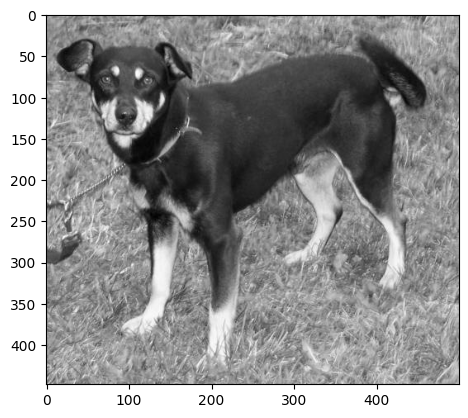

In [ ]:
DATADIR = "/content/PetImages"  # <- change this to the path that contains your Dog/ and Cat/ folders
# this is the directory of your datasets
CATEGORIES = ["Dog", "Cat"]   # Defining the label as "Dog" or "Cat"

for category in CATEGORIES:
    path = os.path.join(DATADIR, category)  # path to cats or dogs dir
    for img in os.listdir(path):
        img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
        if img_array is None:
            # a handful of files in the Kaggle dataset are corrupted/unreadable - skip them
            continue

        # reading the image in the path and transforming it into an array
        # cv2.IMREAD_GRAYSCALE converts the image to grayscale so the CNN only has
        # to learn from one color channel instead of three (faster, smaller model)

        plt.imshow(img_array, cmap="gray")
        plt.show()
        break
    break

## Image Inspection

In [ ]:
print(img_array)          # Displaying the image in array form (just for checking)
print(img_array.shape)    # checking the resolution of the image

[[ 98 141 159 ... 136 145 147]
 [132 152 159 ... 139 141 136]
 [155 157 162 ... 143 143 136]
 ...
 [132 120 121 ... 163 177 182]
 [122 121 147 ... 177 180 188]
 [108 140 211 ... 187 184 193]]
(448, 500)


## Image Resizing

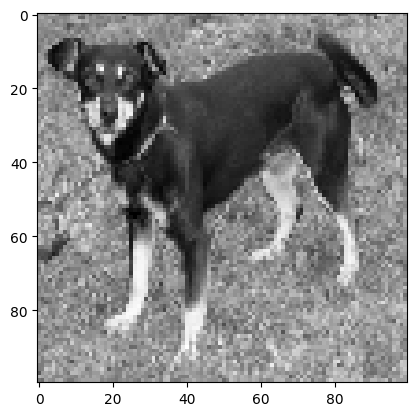

In [ ]:
IMG_SIZE = 100  # initializing variable "IMG_SIZE" as 100

new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
plt.imshow(new_array, cmap='gray')
plt.show()

## Assigning Training Data

In [9]:
training_data = []  # assigning training data

def create_training_data():
    for category in CATEGORIES:
        path = os.path.join(DATADIR, category)  # path to cats or dogs dir
        class_num = CATEGORIES.index(category)
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                training_data.append([new_array, class_num])
            except Exception as e:
                pass

create_training_data()

## Checking the Number of Training Data

In [10]:
print(len(training_data))

24997


## Randomizing/Shuffling the Data

In [12]:
import random
random.shuffle(training_data)

for sample in training_data[:10]:
    print(sample[1])

1
0
1
1
0
0
0
1
0
1


## Assigning Variables for Features and Labels

In [13]:
X = []  # feature set
y = []  # labels

for features, label in training_data:
    X.append(features)
    y.append(label)

X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 1)  # 1 is for grayscale
y = np.array(y)  # Keras expects the labels as an array too

## Using the Pickle Module

In [14]:
import pickle  # pickle lets you save your training data, avoiding recreating it
                # from scratch every time you want to adjust the model

with open('X.pickle', 'wb') as f:
    pickle.dump(X, f)

with open('y.pickle', 'wb') as g:
    pickle.dump(y, g)

## Using Pickle (Loading It Back)

In [15]:
pickle_in = open('X.pickle', 'rb')
X = pickle.load(pickle_in)

X[1]

array([[[ 51],
        [ 51],
        [ 50],
        ...,
        [ 11],
        [ 14],
        [ 12]],

       [[ 54],
        [ 58],
        [ 50],
        ...,
        [ 15],
        [ 13],
        [ 13]],

       [[ 48],
        [ 59],
        [ 58],
        ...,
        [ 17],
        [ 16],
        [ 15]],

       ...,

       [[150],
        [148],
        [143],
        ...,
        [ 58],
        [ 71],
        [ 60]],

       [[133],
        [144],
        [145],
        ...,
        [ 80],
        [ 87],
        [ 77]],

       [[130],
        [145],
        [152],
        ...,
        [ 64],
        [ 80],
        [ 78]]], dtype=uint8)

## What is a CNN?

**CNN** stands for **Convolutional Neural Network** — a type of neural network especially well suited to image data because it learns spatial patterns (edges, textures, shapes) through convolution and pooling layers instead of treating every pixel independently.

Further reading:
- https://medium.com/data-science-group-iitr/building-a-convolutional-neural-network-in-python-with-tensorflow-d251c3ca8117
- https://hackernoon.com/what-is-a-capsnet-or-capsule-network-2bfbe48769cc

## Using a CNN for Classification of Images

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
import pickle

X = pickle.load(open('X.pickle', 'rb'))
y = pickle.load(open('y.pickle', 'rb'))

In [18]:
import pickle

# 1. Reload X and y from the pickle files
with open('X.pickle', 'rb') as f:
    X = pickle.load(f)

with open('y.pickle', 'rb') as f:
    y = pickle.load(f)

# 2. Normalize X ONCE (scale 0-255 down to 0.0-1.0)
X = X / 255.0

# 3. Print the maximum value of X to verify
print("X.max():", X.max())

X.max(): 1.0


In [19]:
import gc
from sklearn.model_selection import train_test_split

# 1. Perform stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Delete original X to save RAM and trigger garbage collection
del X
gc.collect()

# 3. Print the shapes of train and test sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (19997, 100, 100, 1)
X_test shape: (5000, 100, 100, 1)


## Building, Compiling, and Training the CNN

`X = X/255.0` normalizes the pixel values (0-255) down to the 0-1 range, which helps the network train faster and more stably.

> Training for the full 200 epochs on the whole dataset can take a long time on CPU. Reduce `epochs` (e.g. to 10) for a quick test run, and increase it back up once you know the pipeline works.

In [ ]:
X = X / 255.0

model = Sequential()
model.add(Input(shape=X.shape[1:]))

model.add(Conv2D(2, (3, 3)))
#model.add(Conv2D(64, (3, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(64))
model.add(Dense(64))
model.add(Dense(1))
model.add(Activation('sigmoid'))

model.compile(loss="binary_crossentropy",
              optimizer="adam",
              metrics=['accuracy'])



In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 2)      │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 98, 98, 2)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 2)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 47, 47, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 21, 21, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       409,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 452,053 (1.72 MB)

 Trainable params: 452,053 (1.72 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X, y, batch_size=128, epochs=5, validation_split=0.2)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.6326 - loss: 0.6324 - val_accuracy: 0.7164 - val_loss: 0.5650
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 214s 1s/step - accuracy: 0.7369 - loss: 0.5347 - val_accuracy: 0.7370 - val_loss: 0.5341
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 207s 1s/step - accuracy: 0.7703 - loss: 0.4838 - val_accuracy: 0.7736 - val_loss: 0.4844
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.7934 - loss: 0.4431 - val_accuracy: 0.7676 - val_loss: 0.4868
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 174s 1s/step - accuracy: 0.8194 - loss: 0.3985 - val_accuracy: 0.7862 - val_loss: 0.4650


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 2)      │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 98, 98, 2)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 2)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 47, 47, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 21, 21, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       409,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,356,161 (5.17 MB)

 Trainable params: 452,053 (1.72 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 904,108 (3.45 MB)

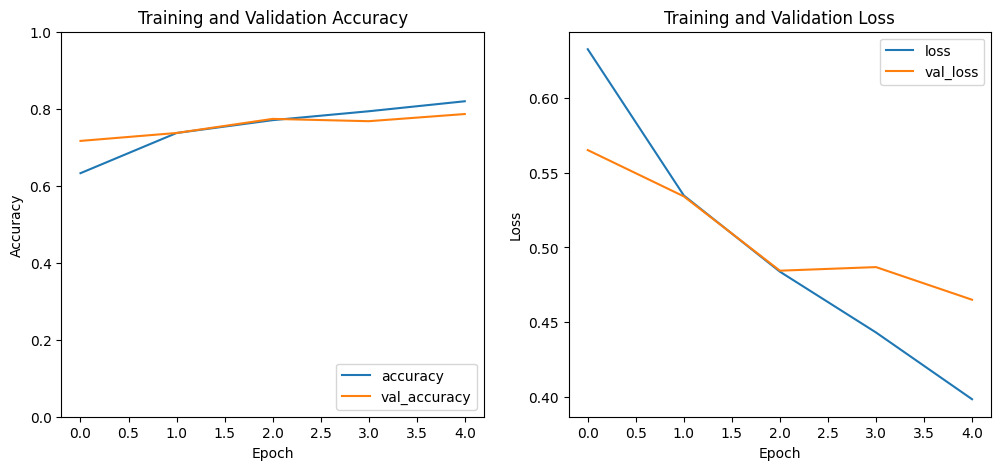

782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 72ms/step

Confusion Matrix:
[[ 9887  2612]
 [ 1493 11005]]


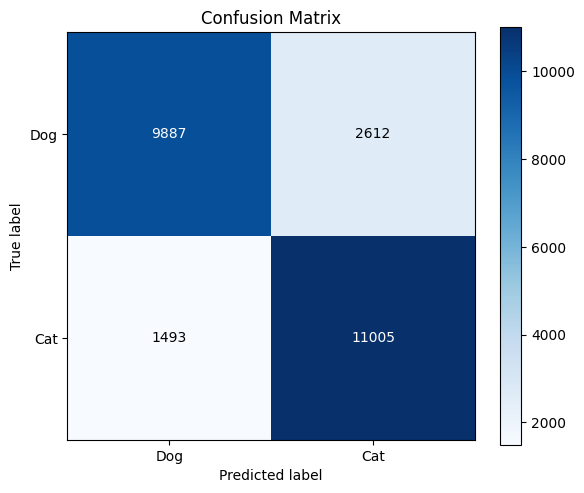

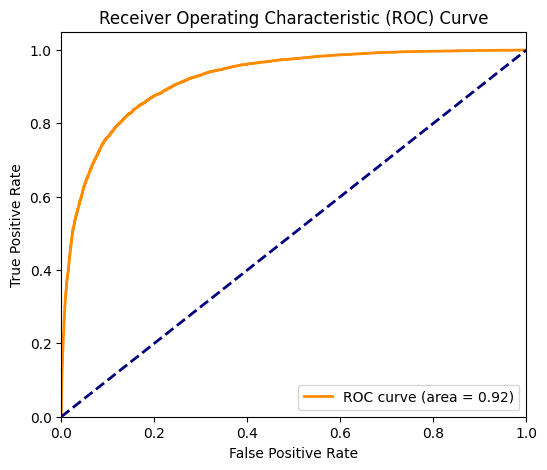

In [ ]:
model.summary()

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
import numpy as np # numpy is already imported as np earlier

# Plot training accuracy and loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

# Get predictions for confusion matrix and ROC
y_pred_proba = model.predict(X).ravel() # .ravel() to flatten to 1D array
y_pred = (y_pred_proba > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y, y_pred)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(np.unique(y)))
CATEGORIES = ["Dog", "Cat"]
plt.xticks(tick_marks, CATEGORIES)
plt.yticks(tick_marks, CATEGORIES)
plt.ylabel('True label')
plt.xlabel('Predicted label')
fmt = 'd'
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], fmt),
             ha="center", va="center",
             color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()

# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
import tensorflow as tf

# Define the filename for your model
model_filename = 'dog_cat_classifier.keras' # .keras is the recommended extension for Keras models

# Save the model
model.save(model_filename)
print(f"Model saved to {model_filename}")

# To load the model later (you can do this in a new session or script)
loaded_model = tf.keras.models.load_model(model_filename)
print(f"Model loaded from {model_filename}")

# You can then use the loaded_model for predictions or further evaluation
# For example, let's make predictions with the loaded model and compare
loaded_model_predictions = loaded_model.predict(X)
print("\nExample predictions from loaded model:")
print(loaded_model_predictions[:5])


Model saved to dog_cat_classifier.keras
Model loaded from dog_cat_classifier.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 60s 77ms/step

Example predictions from loaded model:
[[0.10723565]
 [0.9866128 ]
 [0.9466528 ]
 [0.07590993]
 [0.932677  ]]


## Prediction Inference

Now that the model is loaded, we can use it to make predictions on new, unseen data. For demonstration purposes, I'll take a few samples from your existing `X` data to illustrate how to get predictions from the `loaded_model`.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Predictions for the test samples:
Sample 1: Predicted Class = Dog (Probability: 10.72%) 
Sample 2: Predicted Class = Cat (Probability: 98.66%) 
Sample 3: Predicted Class = Cat (Probability: 94.67%) 
Sample 4: Predicted Class = Dog (Probability: 7.59%) 
Sample 5: Predicted Class = Cat (Probability: 93.27%) 


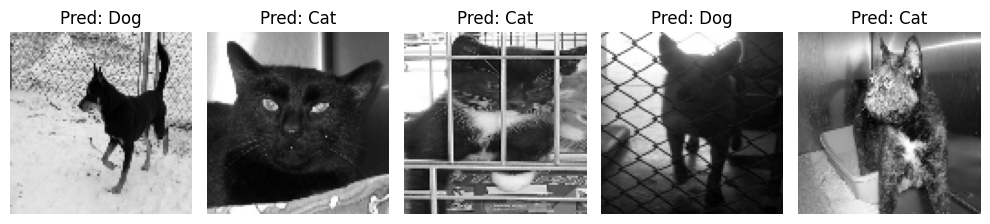

In [ ]:
# Select a small subset of data for inference (e.g., the first 5 samples)
# In a real scenario, this would be entirely new, unseen test data.
test_samples = X[:5]

# Make predictions using the loaded model
inference_predictions = loaded_model.predict(test_samples)

print("Predictions for the test samples:")
for i, prediction in enumerate(inference_predictions):
    # Assuming binary classification with sigmoid output, values close to 1 are 'Cat', close to 0 are 'Dog'
    predicted_class = 'Cat' if prediction[0] > 0.5 else 'Dog'
    probability = prediction[0] * 100
    print(f"Sample {i+1}: Predicted Class = {predicted_class} (Probability: {probability:.2f}%) ")

# Optionally, display the images and their predictions
plt.figure(figsize=(10, 4))
for i in range(min(5, len(test_samples))):
    plt.subplot(1, 5, i + 1)
    plt.imshow(test_samples[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    predicted_class = 'Cat' if inference_predictions[i][0] > 0.5 else 'Dog'
    plt.title(f"Pred: {predicted_class}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Hyperparameter Optimization with Keras Tuner

The CNN above used one fixed, hand-picked set of hyperparameters (a very thin first conv layer with only 2 filters, no dropout, a single learning rate, and a batch size chosen without any experimentation). This section uses [Keras Tuner](https://keras.io/keras_tuner/) to search over several hyperparameters automatically and picks the configuration that gets the best validation accuracy, instead of guessing.

Hyperparameters tuned in this section:

- **Number of convolutional blocks** (2–4)
- **Filters per convolutional layer** (32–256, in steps of 32)
- **Kernel size per convolutional layer** (3×3 or 5×5)
- **Number of dense layers** (1–2) and their **width** (32–256 units)
- **Dropout rate** (0.0–0.5) — the original model had no dropout at all, which is a common cause of overfitting
- **Learning rate** (1e-4 to 1e-2, sampled on a log scale)
- **Optimizer** (Adam vs. RMSprop)
- **Batch size** (32, 64, or 128)

> **Compute note:** hyperparameter search trains many candidate models, so it takes noticeably longer than training a single model. On Colab, switch to a GPU runtime (Runtime → Change runtime type → GPU) before running the cells below. If you just want to see the mechanism work, lower `max_epochs` in the tuner and `epochs` in `tuner.search(...)` first, then raise them once you know it runs end to end.

In [20]:
# Run this once if keras-tuner isn't already installed.
%pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.1 MB/s eta 0:00:00


In [21]:
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

# 1. Split X_train and y_train 80/20 into training (X_tr) and validation (X_val)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# 2. Print shapes to verify the split (X_test remains untouched for final comparison)
print("X_tr shape:", X_tr.shape)
print("X_val shape:", X_val.shape)
print("y_tr shape:", y_tr.shape)
print("y_val shape:", y_val.shape)

X_tr shape: (15997, 100, 100, 1)
X_val shape: (4000, 100, 100, 1)
y_tr shape: (15997,)
y_val shape: (4000,)


In [24]:
def build_model(hp):
    """Builds a CNN whose architecture and optimizer are controlled by `hp`."""
    model = Sequential()
    model.add(Input(shape=X_tr.shape[1:]))

    # Number of convolutional blocks: 2 to 4
    n_conv_layers = hp.Int("n_conv_layers", min_value=2, max_value=4, step=1)

    for i in range(n_conv_layers):
        filters = hp.Int(f"filters_{i}", min_value=32, max_value=256, step=32)
        kernel_size = hp.Choice(f"kernel_size_{i}", values=[3, 5])
        model.add(Conv2D(filters, (kernel_size, kernel_size), padding="same"))
        model.add(Activation("relu"))
        model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())

    # Number of dense layers: 1 to 2, each with its own tunable width
    n_dense_layers = hp.Int("n_dense_layers", min_value=1, max_value=2, step=1)
    for j in range(n_dense_layers):
        dense_units = hp.Int(f"dense_units_{j}", min_value=32, max_value=256, step=32)
        model.add(Dense(dense_units))
        model.add(Activation("relu"))

    # Dropout to fight overfitting - the original model had none
    dropout_rate = hp.Float("dropout_rate", min_value=0.0, max_value=0.5, step=0.1)
    model.add(Dropout(dropout_rate))

    model.add(Dense(1))
    model.add(Activation("sigmoid"))

    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")
    optimizer_choice = hp.Choice("optimizer", values=["adam", "rmsprop"])

    if optimizer_choice == "adam":
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)

    model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])
    return model


class CNNHyperModel(kt.HyperModel):
    """Wraps build_model so batch size can be tuned alongside architecture."""

    def build(self, hp):
        return build_model(hp)

    def fit(self, hp, model, *args, **kwargs):
        batch_size = hp.Choice("batch_size", values=[32, 64, 128])
        return model.fit(*args, batch_size=batch_size, **kwargs)

In [26]:
tuner = kt.Hyperband(
    CNNHyperModel(),
    objective="val_accuracy",
    max_epochs=6,
    factor=3,
    directory="kt_dir",
    project_name="dogs_vs_cats_tuning",
    overwrite=True,
)

tuner.search_space_summary()

stop_early = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

tuner.search(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=6,
    callbacks=[stop_early],
    verbose=1,
)

Trial 10 Complete [00h 02m 18s]
val_accuracy: 0.8029999732971191

Best val_accuracy So Far: 0.8240000009536743
Total elapsed time: 00h 16m 12s


In [27]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best hyperparameters found:")
for param, value in best_hp.values.items():
    print(f"  {param}: {value}")

Best hyperparameters found:
  n_conv_layers: 4
  filters_0: 64
  kernel_size_0: 3
  filters_1: 128
  kernel_size_1: 3
  n_dense_layers: 2
  dense_units_0: 192
  dropout_rate: 0.1
  learning_rate: 0.0003918641276645972
  optimizer: rmsprop
  tuner/epochs: 6
  tuner/initial_epoch: 2
  tuner/bracket: 1
  tuner/round: 1
  filters_2: 32
  kernel_size_2: 3
  filters_3: 32
  kernel_size_3: 3
  dense_units_1: 32
  batch_size: 32
  tuner/trial_id: 0000


## Training the Tuned Model

We rebuild a fresh model with the winning hyperparameters and train it for longer, this time with two callbacks the original notebook didn't use:

- **`EarlyStopping`** stops training once validation loss stops improving, restoring the best weights seen — this avoids wasting epochs (and overfitting) once the model has plateaued.
- **`ReduceLROnPlateau`** halves the learning rate when validation loss stalls, which often squeezes out a bit more accuracy near the end of training.

In [28]:
best_model = tuner.hypermodel.build(best_hp)
tuned_batch_size = best_hp.get("batch_size")

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)

tuned_history = best_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    batch_size=tuned_batch_size,
    epochs=50,
    callbacks=[early_stop, reduce_lr],
)

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.5834 - loss: 0.6660 - val_accuracy: 0.6998 - val_loss: 0.5761 - learning_rate: 3.9186e-04
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.7178 - loss: 0.5502 - val_accuracy: 0.7190 - val_loss: 0.5463 - learning_rate: 3.9186e-04
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.7632 - loss: 0.4927 - val_accuracy: 0.7470 - val_loss: 0.5184 - learning_rate: 3.9186e-04
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.7937 - loss: 0.4438 - val_accuracy: 0.7977 - val_loss: 0.4304 - learning_rate: 3.9186e-04
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.8220 - loss: 0.3970 - val_accuracy: 0.8073 - val_loss: 0.4162 - learning_rate: 3.9186e-04
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.8459 - loss: 0.3574 - val_accuracy: 0.8207 - val_loss: 0.3859 - learning_rate: 3.9186e-04
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/ste

In [29]:
# Evaluate the best tuned model on the untouched test set
test_loss, test_acc = best_model.evaluate(X_test, y_test)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8628 - loss: 0.3518

Test Loss: 0.3518
Test Accuracy: 0.8628


In [ ]:
best_model.summary()

# Plot tuned model's training accuracy and loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(tuned_history.history['accuracy'], label='accuracy')
plt.plot(tuned_history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('Tuned Model: Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(tuned_history.history['loss'], label='loss')
plt.plot(tuned_history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Tuned Model: Training and Validation Loss')

plt.show()

# Evaluate on the held-out validation split (never used for training or search decisions
# beyond early stopping/LR scheduling, so this is a fair estimate of generalization)
val_pred_proba = best_model.predict(X_val).ravel()
val_pred = (val_pred_proba > 0.5).astype(int)

cm_tuned = confusion_matrix(y_val, val_pred)
print("\nTuned Model Confusion Matrix (validation set):")
print(cm_tuned)

plt.figure(figsize=(6, 5))
plt.imshow(cm_tuned, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Tuned Model Confusion Matrix (Validation Set)')
plt.colorbar()
tick_marks = np.arange(len(CATEGORIES))
plt.xticks(tick_marks, CATEGORIES)
plt.yticks(tick_marks, CATEGORIES)
plt.ylabel('True label')
plt.xlabel('Predicted label')
thresh = cm_tuned.max() / 2.
for i, j in np.ndindex(cm_tuned.shape):
    plt.text(j, i, format(cm_tuned[i, j], 'd'),
             ha="center", va="center",
             color="white" if cm_tuned[i, j] > thresh else "black")
plt.tight_layout()
plt.show()

fpr_tuned, tpr_tuned, _ = roc_curve(y_val, val_pred_proba)
roc_auc_tuned = auc(fpr_tuned, tpr_tuned)

plt.figure(figsize=(6, 5))
plt.plot(fpr_tuned, tpr_tuned, color='darkorange', lw=2,
         label=f'ROC curve (area = {roc_auc_tuned:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Tuned Model: ROC Curve (Validation Set)')
plt.legend(loc="lower right")
plt.show()

In [ ]:
tuned_model_filename = 'dog_cat_classifier_tuned.keras'
best_model.save(tuned_model_filename)
print(f"Tuned model saved to {tuned_model_filename}")